<a href="https://colab.research.google.com/github/mohitgoyal1409/machine_learning/blob/main/48_support_vector_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

In [ ]:
from sklearn.datasets import make_circles

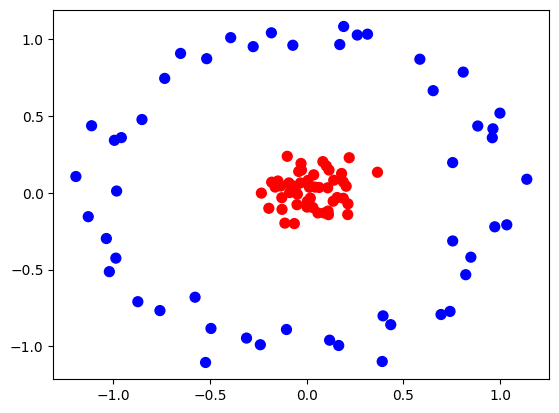

In [ ]:
X, y = make_circles(100, factor = .1, noise = .1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6

In [ ]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(x, y, clf):
      X_set, y_set =x, y
      X1, X2= np.meshgrid(np.arange(start=X_set[:,0].min()-1,
                            stop = X_set[:,0].max() +1,
                            step =0.01),
                         np.arange(start =X_set[:,1].min() -1,
                                      stop = X_set[:,1].max()+1,
                                      step = 0.01))

      plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                  X2.ravel()]).T).reshape(X1.shape),

             alpha = 0.75,
             cmap = zero_one_colourmap)
      plt.xlim(X1.min(),X1.max())
      plt.ylim(X2.min(),X2.max())
      for i, j in enumerate(np.unique(y_set)):
          plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
      c = (zero_one_colourmap)(i), label = j)
      plt.title('SVM Decision Boundary')
      plt.xlabel('X1')
      plt.ylabel('x2')
      plt.legend()
      return plt.show()

/tmp/ipykernel_2633/3228607284.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


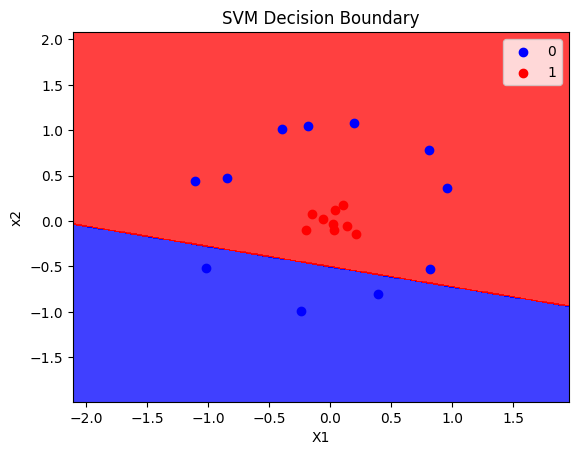

In [ ]:
plot_decision_boundary(X_test, y_test,classifier)

<Axes3D: xlabel='x1', ylabel='x2', zlabel='y'>

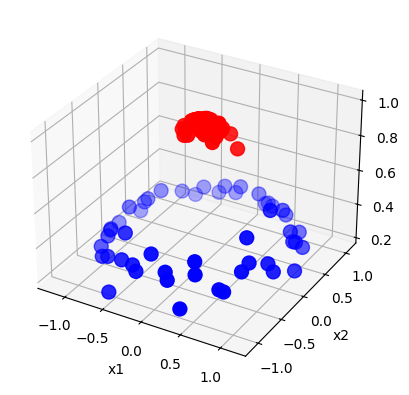

In [ ]:
def plot_3d_plot(x, y):
    r = np.exp(-(x ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('y')
    return ax

plot_3d_plot(X,y)

In [ ]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

1.0

In [ ]:
# plot_decision_boundary(X,y,rbf_classifier)